Exersize 1

[623, 622, 631, 622, 614, 620, 629, 617, 638, 619, 626, 627, 624, 638, 615, 636] bins
1.4159999999999997 chi^2 t-value
0.22026642000000352 KS value


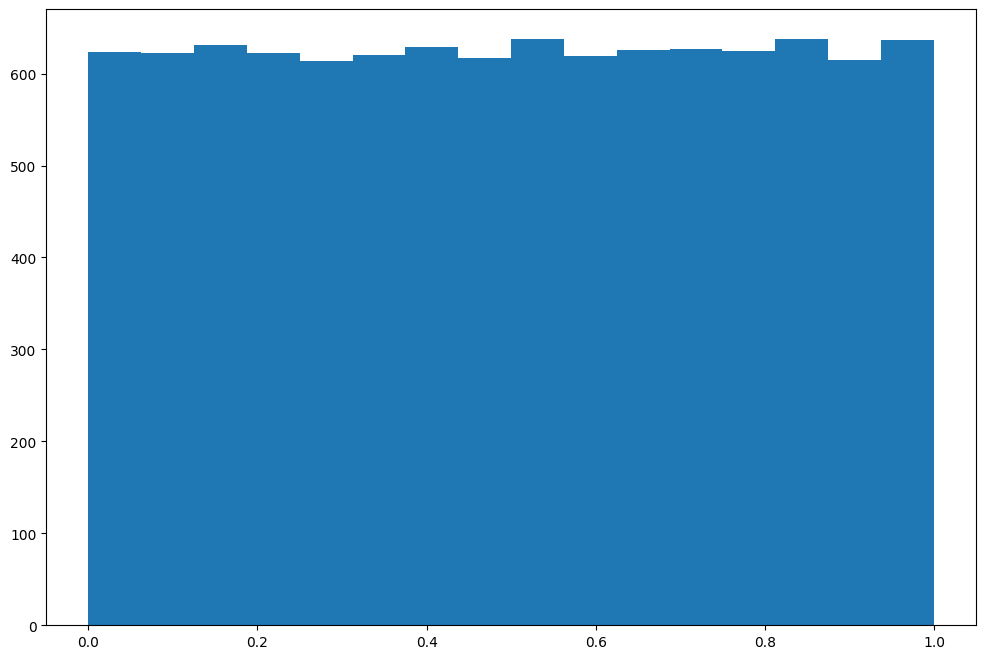

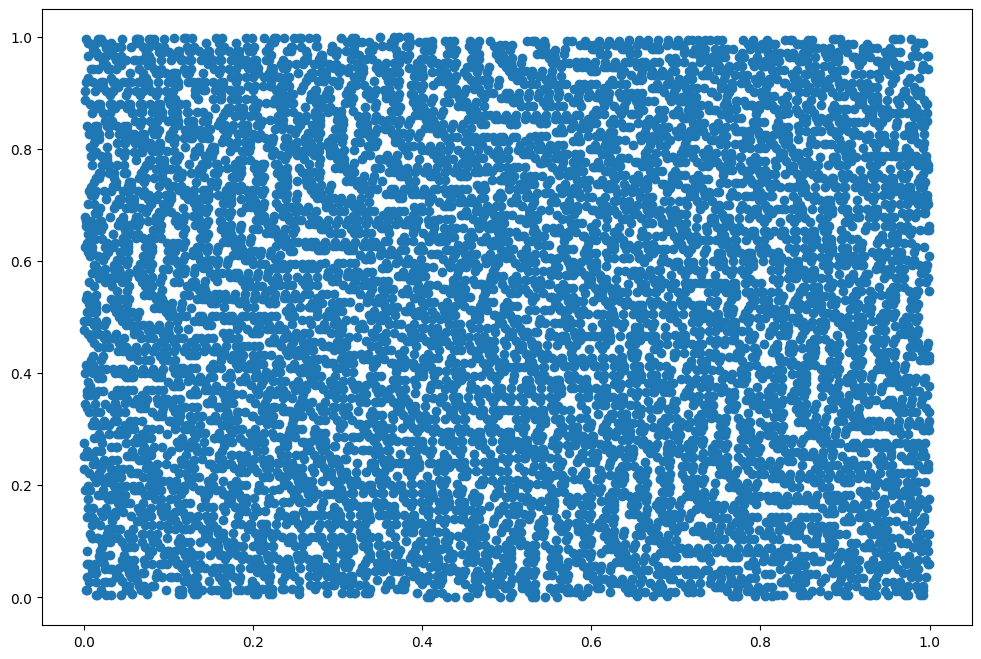

In [93]:
import math as math
import random as rd
import matplotlib.pyplot as plt
import numpy as np
import statistics as stat

def binit(a,count):
    range = max(a)-min(a)
    bin_size = range/count
    binList = [0]*count
    for items in a:
        if items == max(a):
            binList[-1] += 1
        else:
            binList[int((items - min(a))/bin_size)] += 1
    return binList

def chi(real, expected):
    sum_int = 0
    for I in range(len(real)):
        sum_int += ((float(real[I])- float(expected[I]))**2)/float(expected[I])
    return sum_int

def KS(binns_real, binns_theoretical):
    li1 = 0
    li2 = 0
    maxdiff = 0
    for i in range(len(binns_real)):
        li1 += binns_real[i]
        li2 += binns_theoretical[i]
        if abs(li1 - li2) > maxdiff:
            maxdiff = abs(li1 - li2)
    return maxdiff




x = [3]

a = 129
c = 26461
M = 65536
for  I in range(10000):
    x.append(((x[-1]*a + c)%M))
a = [p/M for p in x]

print(str(binit(a,16)) + " bins")
plt.hist(a,16)
print(str(chi(binit(a,16),[625]*16)) + " chi^2 t-value")
l = binit(a,16)
bins = []
for p in l:
    bins.append(p/10000)
    
ks_num = KS(bins,[625/10000]*16)
print(str((math.sqrt(10000) + 0.12 + 0.11/math.sqrt(10000))*ks_num) + " KS value")
plt.show()
plt.scatter(a[1:],a[0:-1])
plt.show()



The Histogram is almost uniform with a chi^2 t-value of ~15 when compared to a perfect uniform distrobution. The plot shows no oviouse patterens between each x_n and the next x_n+1. Also the ks value is 0.22 so we fail to reject the hypothisis that it is not a uniform distrobutin. 

[666, 685, 632, 619, 633, 669, 597, 600, 584, 624, 586, 622, 623, 595, 629, 636] bins
20.8448 chi^2 t-value
1.5418649400000024 KS value


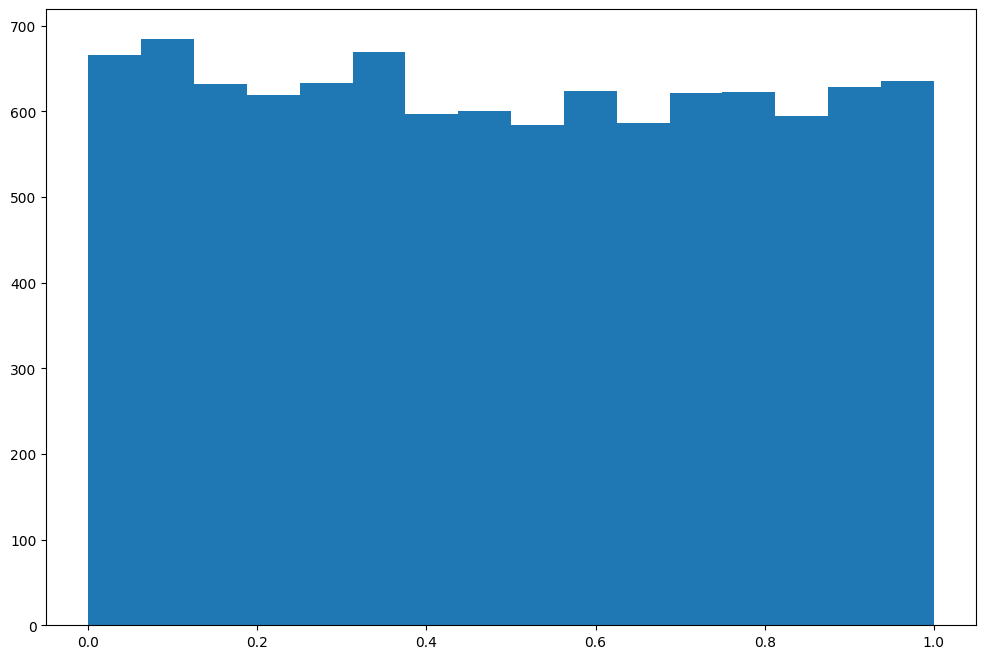

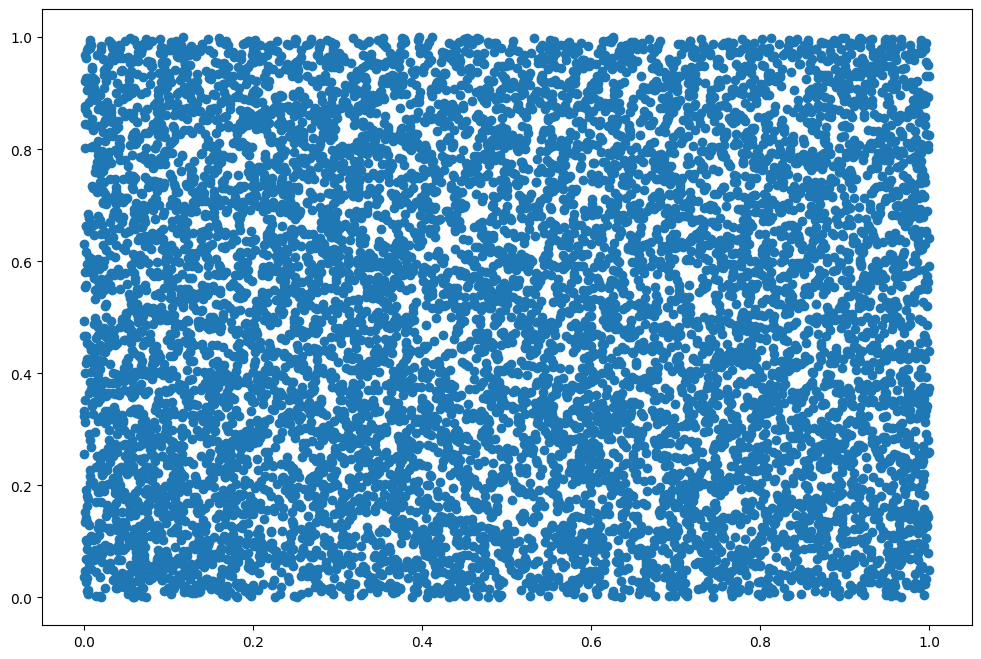

In [94]:
x = []
for  I in range(10000):
    x.append(rd.random())
a = [p for p in x]


plt.hist(a,16)

l = binit(a,16)
bins = []
for p in l:
    bins.append(p/10000)
    
ks_num = KS(bins,[625/10000]*16)


print(str(binit(a,16)) + " bins")
print(str(chi(binit(a,16),[625]*16)) + " chi^2 t-value")
print(str((math.sqrt(10000) + 0.12 + 0.11/math.sqrt(10000))*ks_num) + " KS value")

plt.show()
plt.scatter(a[1:],a[0:-1])
plt.show()

Exersise 2

In [95]:
import time
np.set_printoptions(suppress=True)


def bar_hist(data, bins=0, center_on_int=False):
    data = np.asarray(data)
    if center_on_int:
        min_val = int(np.min(data))
        max_val = int(np.max(data))
        bin_edges = np.arange(min_val, max_val + 2)
        counts, _ = np.histogram(data, bins=bin_edges)
        centers = bin_edges[:-1] + 0.5
    else:
        if bins == 0 and int(max(data) - min(data)) > 0:
            bins = int(max(data) - min(data))
        counts, bin_edges = np.histogram(data, bins)
        centers = bin_edges[:-1] + 0.5

    plt.bar(centers, counts/len(data), width=1, edgecolor='black')
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title("Hist")
    return centers





0.0033304999815300107 seconds to run 10000
22.050238534613534 chi^2


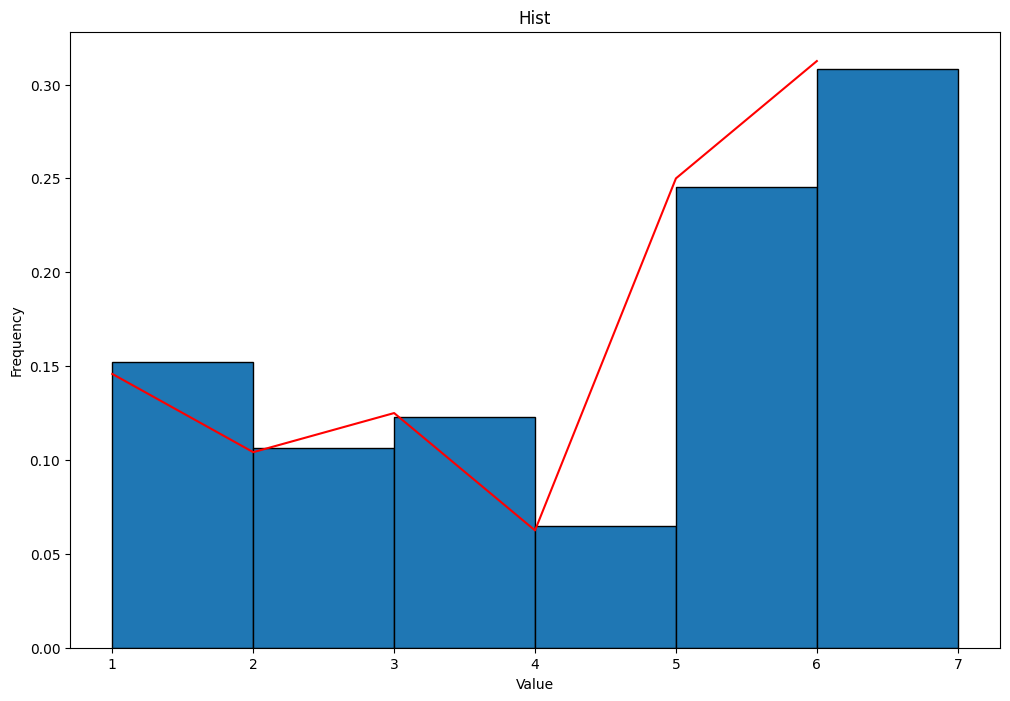

In [96]:
Prob_space= [7/48,5/48,1/8,1/16,1/4,5/16]

def gen_obs(a):
    b = rd.random()
    l = a[0]
    count = 1
    while b > l:
        count += 1
        b = b - l
        l = a[count - 1]
    return count

start_time = time.perf_counter()
l = [gen_obs(Prob_space) for I in range(10000)]
end_time = time.perf_counter()


c = bar_hist([gen_obs(Prob_space) for I in range(10000)],center_on_int=True)

print(str(end_time - start_time) + " seconds to run 10000")
print(str(chi(Prob_space,list(c))) + " chi^2")

plt.plot([1,2,3,4,5,6],Prob_space, color ="red")
plt.show()

0.006062999949790537 seconds to run 10000
22.050238534613534 chi^2


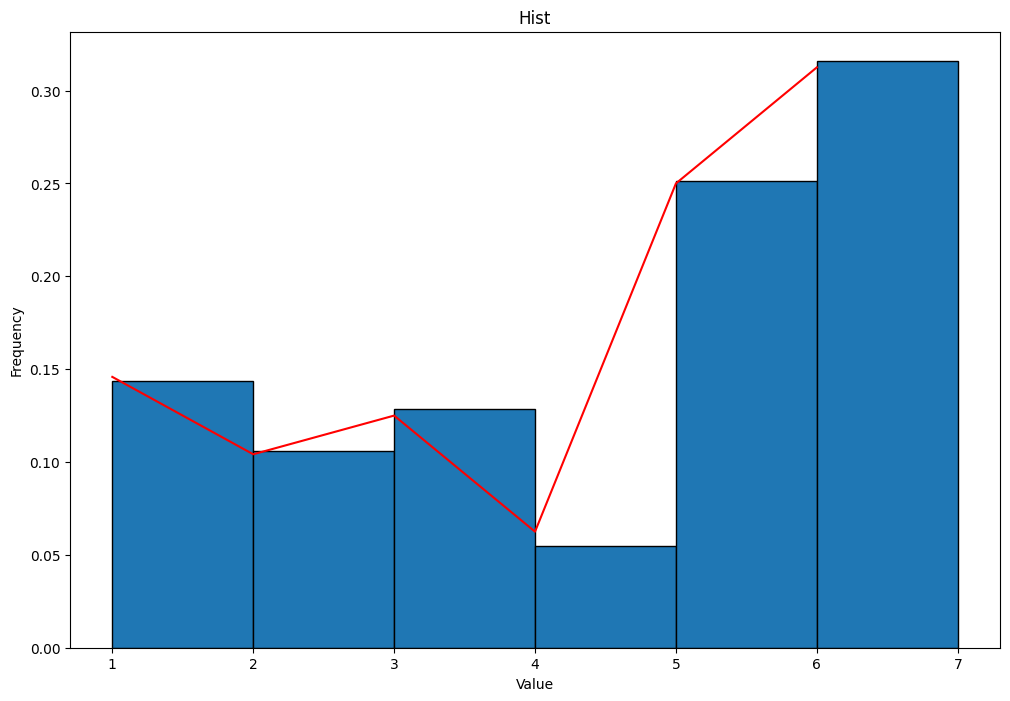

In [97]:
def gen_obs_reg(a):
    I = 0
    c = max(a)
    found = 0
    while found == 0:
        I = int(len(a)*rd.random())+1
        if rd.random() < a[I-1]:
            found = 1
    return I

start_time = time.perf_counter()
l = [gen_obs(Prob_space) for I in range(10000)]
end_time = time.perf_counter()
c = bar_hist([gen_obs(Prob_space) for I in range(10000)],center_on_int=True)
print(str(end_time - start_time) + " seconds to run 10000")
print(str(chi(Prob_space,list(c))) + " chi^2")
plt.plot([1,2,3,4,5,6],Prob_space, color ="red")
plt.show()

0.004938500002026558 seconds to run 10000
22.050238534613534 chi^2


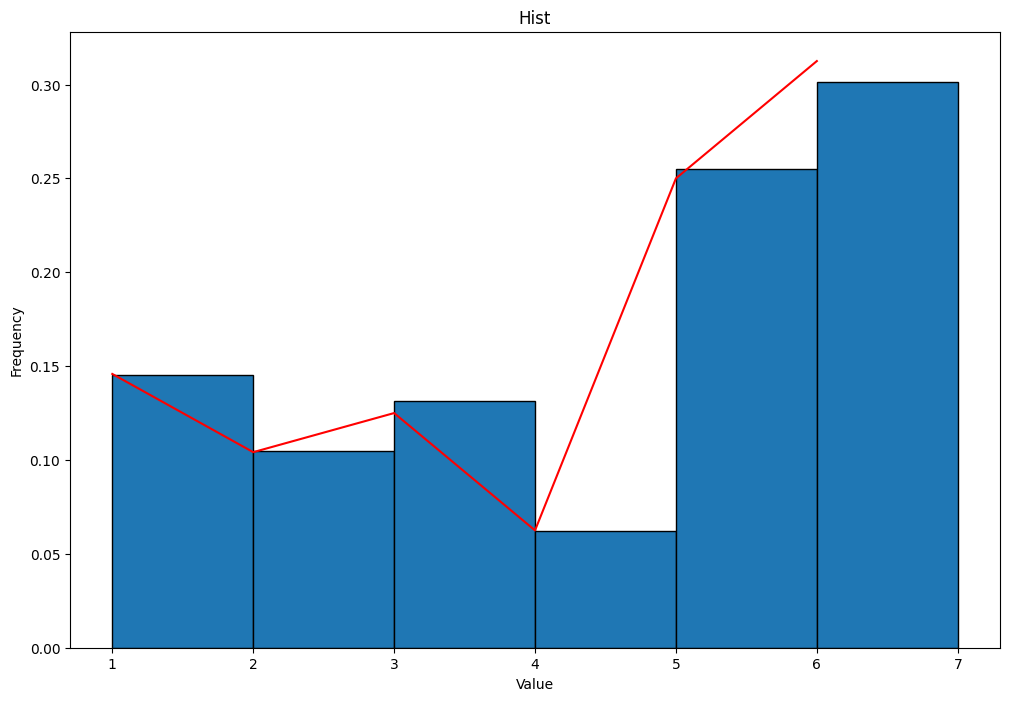

In [98]:
def gen_obs_ali(a,num=1):
    c = sum(a)/len(a)
    cost = [I-c for I in a]
    destination = [[I] for I in range(len(a))]
    accountment = [[min(a[I]/c,1)] for I in range(len(a))]
    while min(cost) < -0.0000001:
        small = cost.index(min(cost))
        big = cost.index(max(cost))
        g = min(cost[big],abs(cost[small]))
        accountment[small].append(sum(accountment[small])+g/c)
        cost[big] -= g
        cost[small] += g
        destination[small].append(big)
    ans = []
    for I in range(num):
        u2 = rd.random()
        u1 = int(rd.random()*len(a)) + 1
        ind = 0
        while u2 > accountment[u1-1][ind]:
            ind += 1
        ans.append(destination[u1-1][ind]+1)
    return ans

start_time = time.perf_counter()
l = gen_obs_ali(Prob_space,10000)
end_time = time.perf_counter()
print(str(end_time - start_time) + " seconds to run 10000")
c = bar_hist(gen_obs_ali(Prob_space,10000),center_on_int=True)
plt.plot([1,2,3,4,5,6],Prob_space, color ="red")
print(str(chi(Prob_space,list(c))) + " chi^2")
plt.show()


Exsersize 3

In [149]:
import math as mth

np.set_printoptions(suppress=True)


def bar_hist(data, bins=0, center_on_int=False):
    data = np.asarray(data)
    if center_on_int:
        min_val = int(np.min(data))
        max_val = int(np.max(data))
        bin_edges = np.arange(min_val, max_val + 2)
        counts, _ = np.histogram(data, bins=bin_edges)
        centers = bin_edges[:-1] + 0.5
    else:
        if bins == 0 and int(max(data) - min(data)) > 0:
            bins = int(max(data) - min(data))
        counts, bin_edges = np.histogram(data, bins)
        centers = bin_edges[:-1] + 0.5

    plt.bar(centers, counts/len(data), width=0.01, edgecolor='black')
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title("Hist")
    return centers, counts/len(data)

def plot_pmf_continuous(data, bins=20):
    counts, bin_edges = np.histogram(data, bins=bins)
    widths = np.diff(bin_edges)
    probs = counts / (counts.sum()*widths)
    centers = bin_edges[:-1] + widths/2

    plt.bar(centers, probs, width=widths, edgecolor='black')
    return counts/len(data), bin_edges


0.01681360012186248 chi^2


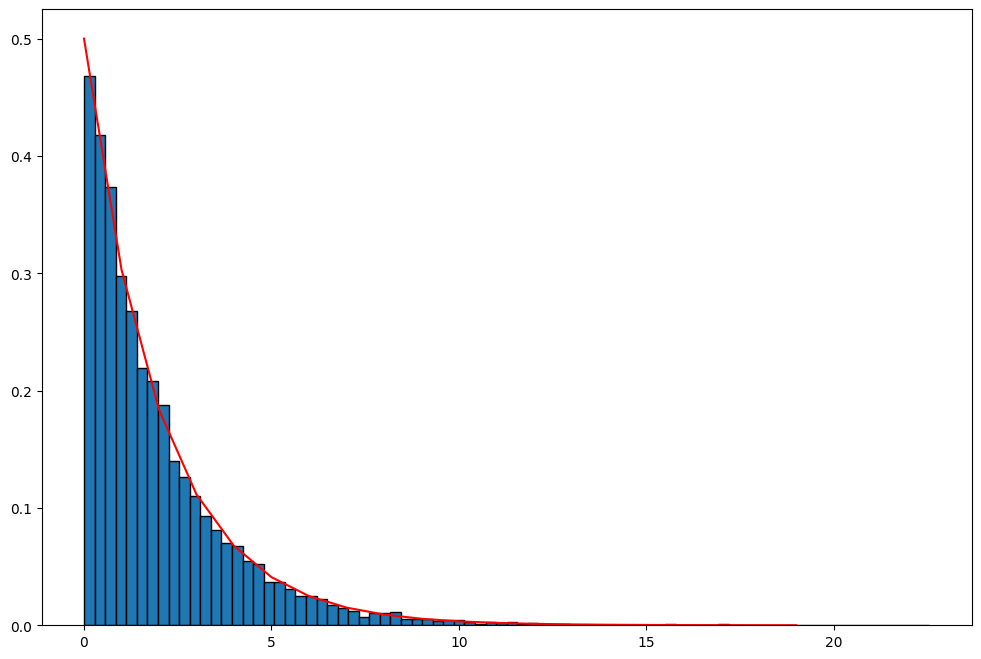

In [138]:
gamma = .5
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100


def exp_rand(gamma):
    return -mth.log(rd.random())/gamma

a = [exp_rand(gamma) for I in range(10000)]
c,b = plot_pmf_continuous(a,80)
plt.plot([I for I in range(20)],[gamma*mth.exp(-gamma*I) for I in range(20)],color="red")


print(str(chi(list(c),[gamma*mth.exp(-gamma*b[I])*(b[I+1] - b[I]) for I in range(len(b)-1)])) + " chi^2")

0.002373413563984809 chi^2


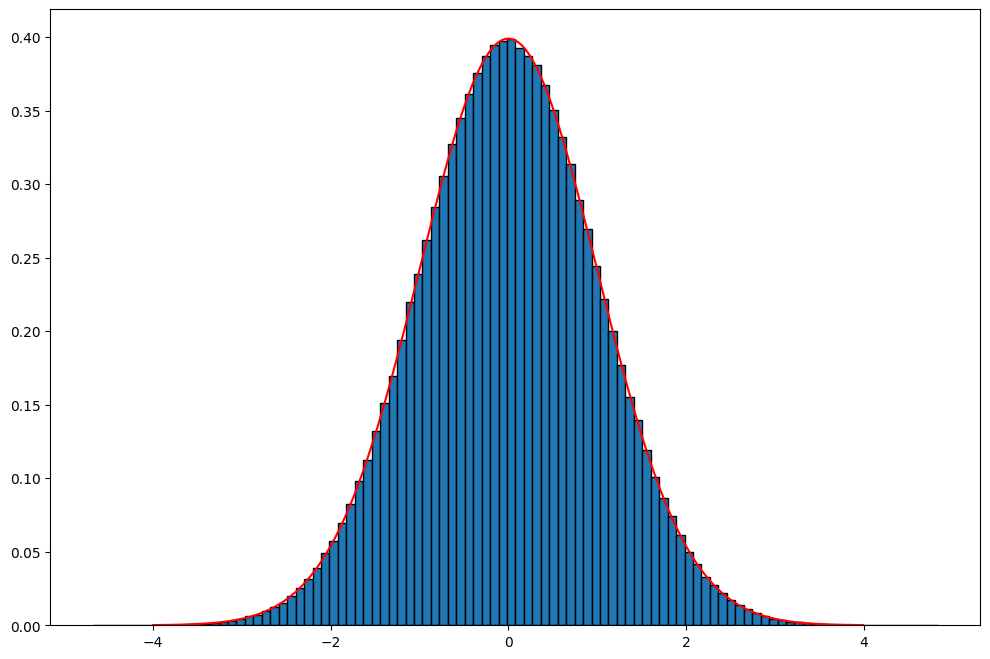

In [ ]:
def Normal_dis():
    return [mth.sqrt(-2*mth.log(rd.random()))*mth.cos(2*mth.pi*rd.random()), mth.sqrt(exp_rand(1/2))*mth.sin(2*mth.pi*rd.random())]



c,b = plot_pmf_continuous([Normal_dis()[0] for I in range(1000000)],100)
plt.plot([(x-4*200)/200 for x in range(8*200)],[(1/np.sqrt(2*np.pi)) * np.exp(-0.5 * ((x-4*200)/200)**2) for x in range(8*200)], color="red")

print(str(chi(list(c),[(1/np.sqrt(2*np.pi)) * np.exp(-0.5 * ((b[I])**2))*(b[I+1] - b[I]) for I in range(len(b)-1)])) + " chi^2")

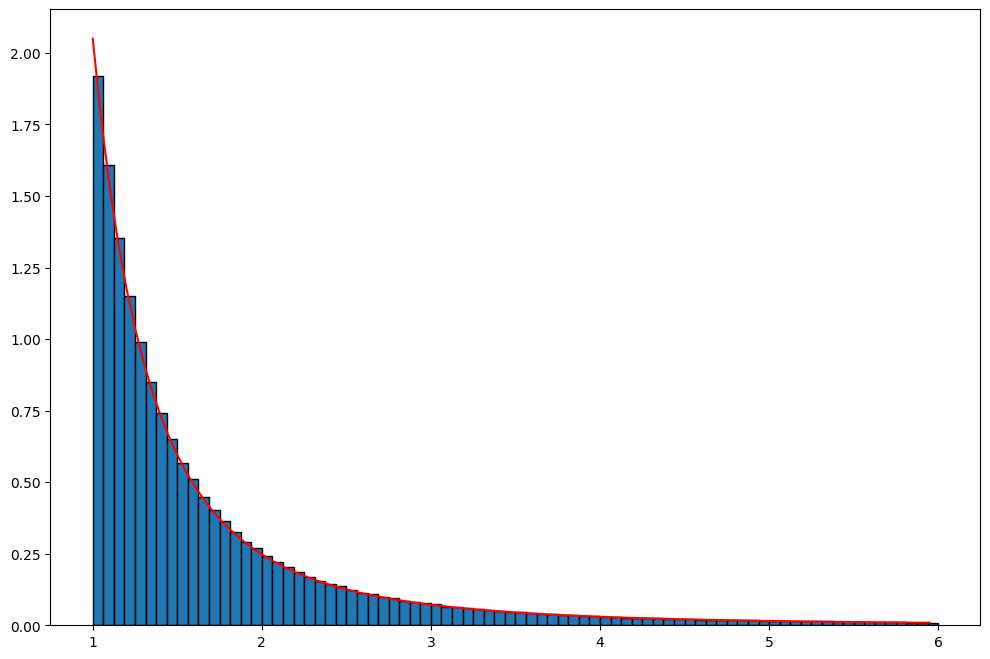

3.3275096012334138 chi^2
Theoretical mean: 1.9523809523809526
Theoretical var: 37.18820861678019
mean: 1.6994007503813924
var: 0.7253608585906899


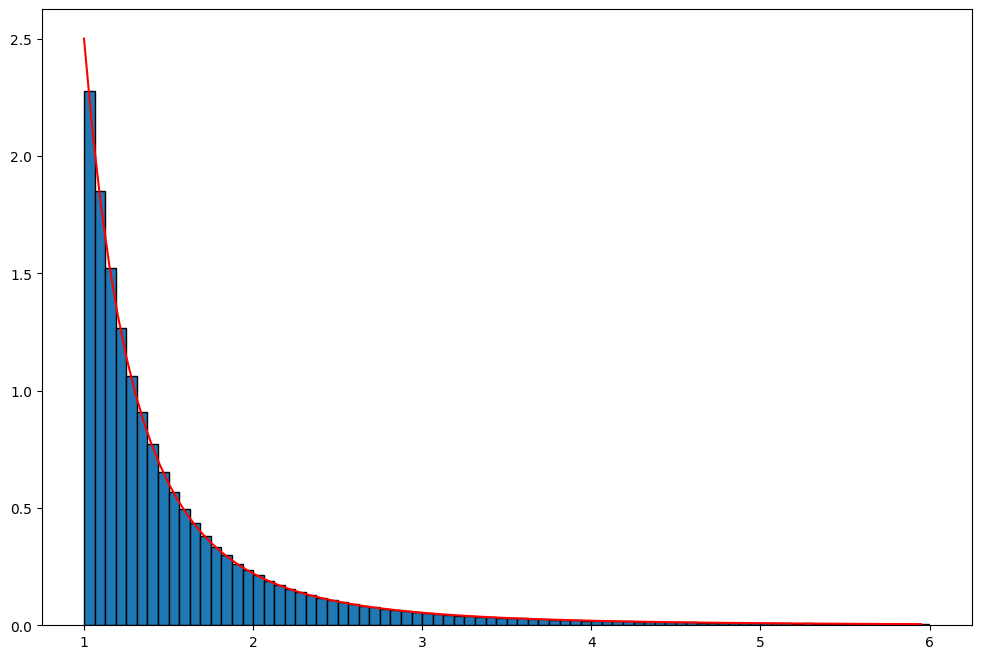

5.004463616059231 chi^2
Theoretical mean: 1.6666666666666667
Theoretical var: 2.2222222222222223
mean: 1.5716228359116395
var: 0.5262725733544694


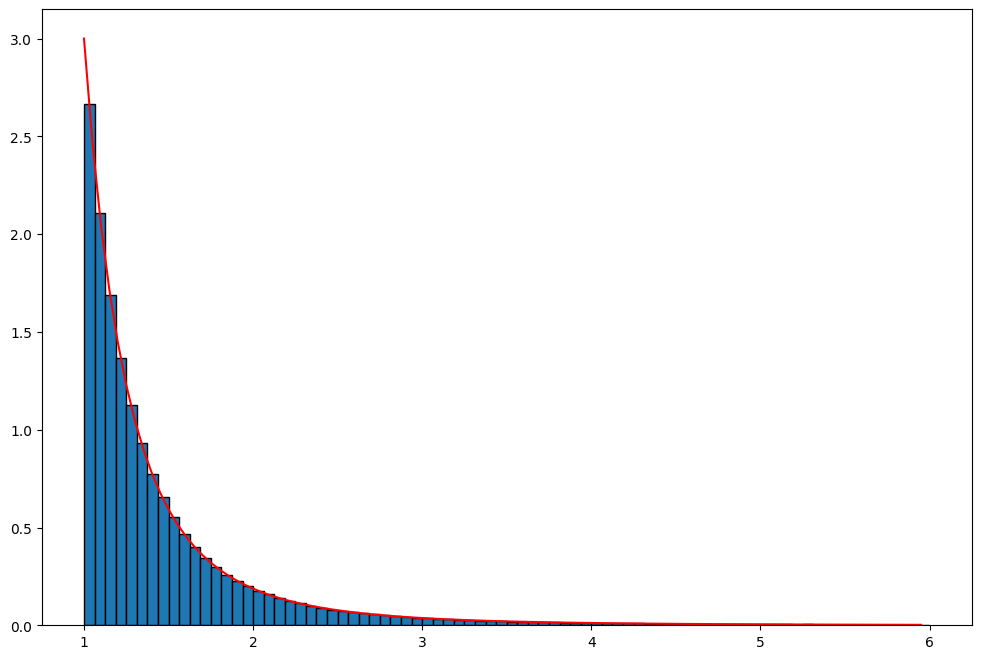

7.68361837483744 chi^2
Theoretical mean: 1.5
Theoretical var: 0.75
mean: 1.465433000601146
var: 0.366428313752756


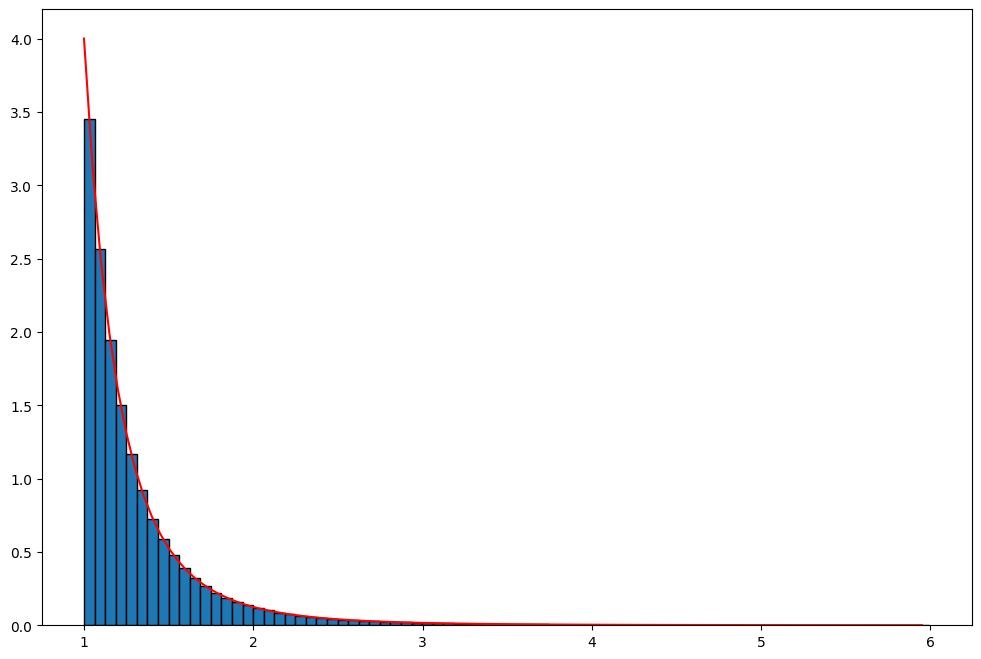

16.999307186079193 chi^2
Theoretical mean: 1.3333333333333333
Theoretical var: 0.2222222222222222
mean: 1.3282522971933675
var: 0.18243185739515916


In [168]:
def pareto(mean, k):
    b = mean*(k-1)/k
    return b*((1-rd.random())**(-1/k))

k = 2.05
b = 1
p = [ pareto(k/(k-1),k) for I in range(1000000)]
a=[]
for J in p:
    if J < 6:
        a.append(J)

l , p = plot_pmf_continuous(a,80)
plt.plot([I/20+1 for I in range(100)],[k*(b**k)/((I/20+1)**(k+1)) for I in range(100)],color="red")
plt.show()


print(str(chi(list(l),[(k*(b**k)/((p[I]+1)**(k+1)))*(p[I+1] - p[I]) for I in range(len(p)-1)])) + " chi^2")


print("Theoretical mean: " + str(k/(k-1)))
print("Theoretical var: " + str(k/((k-2)*(k-1)**2)))
print("mean: " + str(sum(a)/len(a)))
print("var: " + str(stat.variance(a)))




k = 2.5
b = 1
p = [ pareto(k/(k-1),k) for I in range(1000000)]
a=[]
for J in p:
    if J < 6:
        a.append(J)

l , p = plot_pmf_continuous(a,80)
plt.plot([I/20+1 for I in range(100)],[k*(b**k)/((I/20+1)**(k+1)) for I in range(100)],color="red")
plt.show()


print(str(chi(list(l),[(k*(b**k)/((p[I]+1)**(k+1)))*(p[I+1] - p[I]) for I in range(len(p)-1)])) + " chi^2")


print("Theoretical mean: " + str(k/(k-1)))
print("Theoretical var: " + str(k/((k-2)*(k-1)**2)))
print("mean: " + str(sum(a)/len(a)))
print("var: " + str(stat.variance(a)))





k = 3
b = 1
p = [ pareto(k/(k-1),k) for I in range(1000000)]
a=[]
for J in p:
    if J < 6:
        a.append(J)

l , p = plot_pmf_continuous(a,80)
plt.plot([I/20+1 for I in range(100)],[k*(b**k)/((I/20+1)**(k+1)) for I in range(100)],color="red")
plt.show()


print(str(chi(list(l),[(k*(b**k)/((p[I]+1)**(k+1)))*(p[I+1] - p[I]) for I in range(len(p)-1)])) + " chi^2")


print("Theoretical mean: " + str(k/(k-1)))
print("Theoretical var: " + str(k/((k-2)*(k-1)**2)))
print("mean: " + str(sum(a)/len(a)))
print("var: " + str(stat.variance(a)))





k = 4
b = 1
p = [ pareto(k/(k-1),k) for I in range(1000000)]
a=[]
for J in p:
    if J < 6:
        a.append(J)

l , p = plot_pmf_continuous(a,80)
plt.plot([I/20+1 for I in range(100)],[k*(b**k)/((I/20+1)**(k+1)) for I in range(100)],color="red")
plt.show()


print(str(chi(list(l),[(k*(b**k)/((p[I]+1)**(k+1)))*(p[I+1] - p[I]) for I in range(len(p)-1)])) + " chi^2")


print("Theoretical mean: " + str(k/(k-1)))
print("Theoretical var: " + str(k/((k-2)*(k-1)**2)))
print("mean: " + str(sum(a)/len(a)))
print("var: " + str(stat.variance(a)))

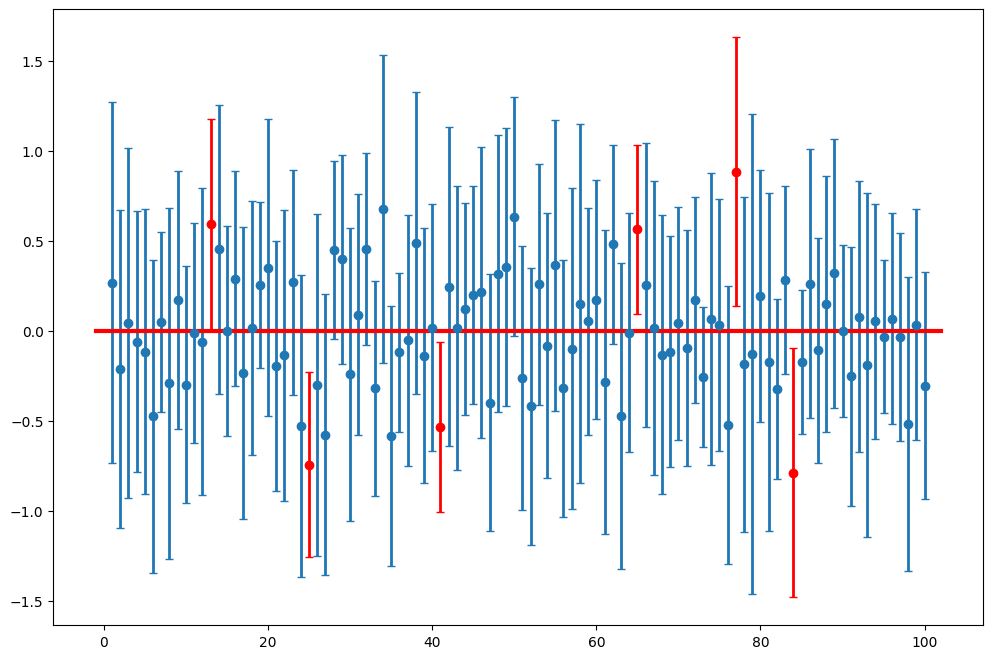

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st


def varInterval(data):
    return [(len(data)-1)*stat.variance()/st.chi2.ppf(0.05/2,(len(data)-1)), (len(data)-1)*stat.variance()/st.chi2.ppf(0.95/2,(len(data)-1))]

x = []
y = []
yerr = []


x2 = []
y2 = []
yerr2 = []

for I in range(100):
    data = []
    for J in range(10):
       data.append(Normal_dis()[0])
    
    inter = st.t.interval(confidence=0.95, df=len(data)-1, loc=np.mean(data), scale=st.sem(data))
    
    if inter[0] > 0 or inter[1] < 0:
        y2.append((inter[0] + inter[1])/2)
        x2.append(I+1)
        yerr2.append(abs(inter[0] - inter[1])/2)
    else:
        y.append((inter[0] + inter[1])/2)
        x.append(I+1)
        yerr.append(abs(inter[0] - inter[1])/2)

# make data:

# plot:
fig, ax = plt.subplots()
fig.set_figwidth(12)
ax.errorbar(x, y, yerr, fmt='o', linewidth=2, capsize=3)
ax.errorbar(x2, y2, yerr2, fmt='o', linewidth=2, capsize=3,color="red")

ax.plot([-1,102],[0,0],color="red",linewidth=3)

plt.show()

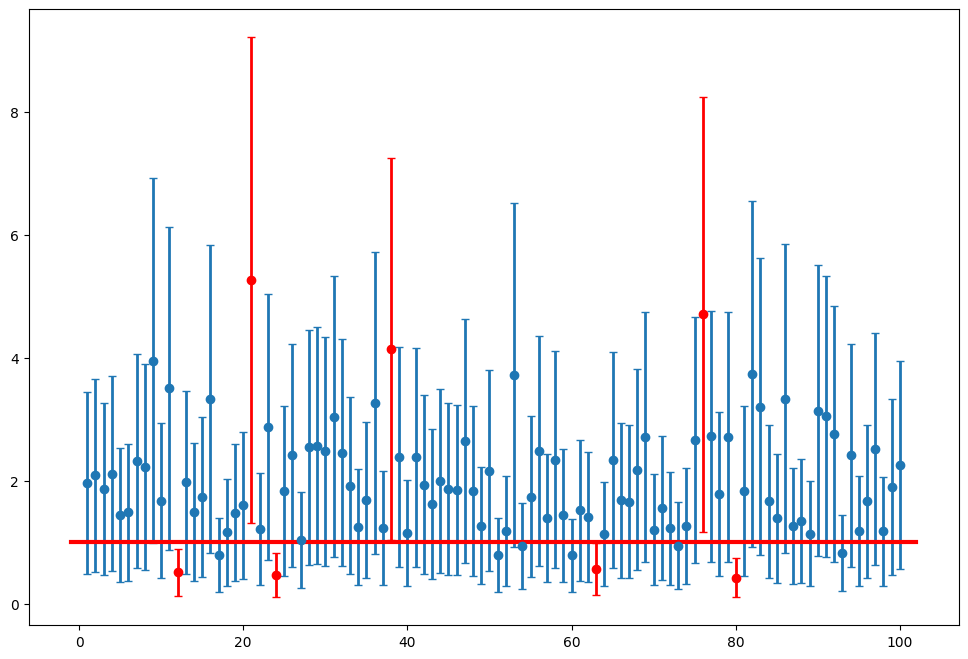

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st


def varInterval(data):
    return [(len(data)-1)*(stat.variance(data))/st.chi2.ppf(1- 0.05/2,(len(data)-1)), (len(data)-1)*(stat.variance(data))/st.chi2.ppf(0.05/2,(len(data)-1))]

x = []
y = []
yerr = []


x2 = []
y2 = []
yerr2 = []

for I in range(100):
    data = []
    for J in range(10):
       data.append(Normal_dis()[0])
    
    inter = varInterval(data)
    
    if inter[0] > 1 or inter[1] < 1:
        y2.append((inter[0] + inter[1])/2)
        x2.append(I+1)
        yerr2.append(abs(inter[0] - inter[1])/2)
    else:
        y.append((inter[0] + inter[1])/2)
        x.append(I+1)
        yerr.append(abs(inter[0] - inter[1])/2)

# make data:

# plot:
fig, ax = plt.subplots()
fig.set_figwidth(12)
ax.errorbar(x, y, yerr, fmt='o', linewidth=2, capsize=3)
ax.errorbar(x2, y2, yerr2, fmt='o', linewidth=2, capsize=3,color="red")

ax.plot([-1,102],[1,1],color="red",linewidth=3)

plt.show()

0.028629489583482028 chi^2


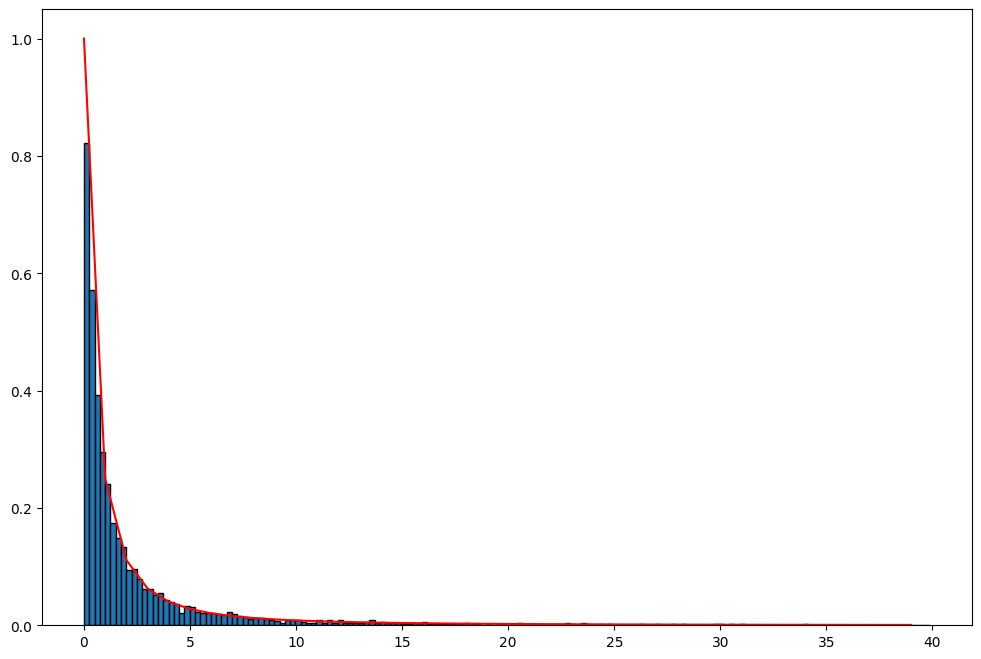

In [ ]:

mean = 1
k=1
b=mean
a = []
for I in range(10000):
    y = exp_rand(mean)
    x = exp_rand(y)
    if x < 40:
        a.append(x)

l , p = plot_pmf_continuous(a,160)
print(str(chi(list(l),[(k*(b**k)/((p[I]+1)**(k+1)))*(p[I+1] - p[I]) for I in range(len(p)-1)])) + " chi^2")
plt.plot([I for I in range(40)],[(k*(b**k)/((I+1)**(k+1))) for I in range(40)], color="red")

Exersize 4

In [174]:
import random as rd
import matplotlib.pyplot as plt
import numpy as np
import math as mth
import queue as q

In [175]:
m = 10


class event():
    def __init__(self, x, y):
        self.type = x
        self.time = y
    def __str__(self):
        return str(self.type)

def exp_rand(gamma):
    return -mth.log(rd.random())/gamma

def inserte_event(que,type,time):
    I = 0
    time_new = 0
    if type == 1:
        time_new = exp_rand(1)
    else:
        time_new = exp_rand(0.125)
    while True:
        if I == len(que) or time + time_new < que[I].time:
            que.insert(I, event(type,time + time_new))
            break
        I += 1

def run_event(m,que,array):
    a = que.pop(0)
    if a.type == 1:
        if m > 0:
            array.append(1)
            m -= 1
            inserte_event(que,2,a.time)
        else:
            array.append(0)
        inserte_event(que,1,a.time)
    if a.type == 2:
        m += 1
    #print('The Que is now: [', end='', flush=True)
    #for I in que:
    #    print(str(I) + ", ", end='', flush=True)
    #print("]")
    return m
l = []
for I in range(10):
    m=10
    que = []
    array = []
    inserte_event(que,1,0)
    for I in range(100000):
        m = run_event(m,que,array)
    l.append(array.count(0)/len(array))
print(sum(l)/len(l))
print(st.t.interval(confidence=0.95, df=len(l)-1, loc=sum(l)/len(l), scale=st.sem(l)))

0.12175636575783892
(np.float64(0.12004872170583325), np.float64(0.1234640098098446))


In [176]:
m = 10


class event():
    def __init__(self, x, y):
        self.type = x
        self.time = y
    def __str__(self):
        return str(self.type)

def exp_rand(gamma):
    return -mth.log(rd.random())/gamma

def Erlang(mean, n):
    a = 1
    for I in range(n):
        a = a*rd.random()
    return -mth.log(a)/(n/mean)

def HyperExp(prob, gammas):
    if abs(sum(prob) - 1) > 0.0000001:
        raise Exception("probabilites do not add too 1")
    a = rd.random()
    I = 0
    while True:
        if a < prob[I]:
            return exp_rand(gammas[I])
        a = a-prob[I]

def inserte_event(que,type,time):
    I = 0
    time_new = 0
    if type == 1:
        time_new = Erlang(1, 8)
    else:
        time_new = exp_rand(0.125)
    while True:
        if I == len(que) or time + time_new < que[I].time:
            que.insert(I, event(type,time + time_new))
            break
        I += 1

def run_event(m,que,array):
    a = que.pop(0)
    if a.type == 1:
        if m > 0:
            array.append(1)
            m -= 1
            inserte_event(que,2,a.time)
        else:
            array.append(0)
        inserte_event(que,1,a.time)
    if a.type == 2:
        m += 1
    #print('The Que is now: [', end='', flush=True)
    #for I in que:
    #    print(str(I) + ", ", end='', flush=True)
    #print("]")
    return m
l = []
for I in range(10):
    m=10
    que = []
    array = []
    inserte_event(que,1,0)
    for I in range(100000):
        m = run_event(m,que,array)
    l.append(array.count(0)/len(array))
print(sum(l)/len(l))
print(st.t.interval(confidence=0.95, df=len(l)-1, loc=sum(l)/len(l), scale=st.sem(l)))

0.06797121442486467
(np.float64(0.06641907063509929), np.float64(0.06952335821463006))


In [180]:
m = 10


class event():
    def __init__(self, x, y):
        self.type = x
        self.time = y
    def __str__(self):
        return str(self.type)

def exp_rand(gamma):
    return -mth.log(rd.random())/gamma

def Erlang(mean, n):
    a = 1
    for I in range(n):
        a = a*rd.random()
    return -mth.log(a)/(n/mean)

def HyperExp(prob, gammas):
    if abs(sum(prob) - 1) > 0.0000001:
        raise Exception("probabilites do not add too 1")
    a = rd.random()
    I = 0
    while True:
        if a < prob[I]:
            return exp_rand(gammas[I])
        a = a-prob[I]

def inserte_event(que,type,time):
    I = 0
    time_new = 0
    if type == 1:
        time_new = HyperExp([0.8,0.2], [0.8333,5.0])
    else:
        time_new = exp_rand(0.125)
    while True:
        if I == len(que) or time + time_new < que[I].time:
            que.insert(I, event(type,time + time_new))
            break
        I += 1

def run_event(m,que,array):
    a = que.pop(0)
    if a.type == 1:
        if m > 0:
            array.append(1)
            m -= 1
            inserte_event(que,2,a.time)
        else:
            array.append(0)
        inserte_event(que,1,a.time)
    if a.type == 2:
        m += 1
    #print('The Que is now: [', end='', flush=True)
    #for I in que:
    #    print(str(I) + ", ", end='', flush=True)
    #print("]")
    return m
l = []
for I in range(10):
    m=10
    que = []
    array = []
    inserte_event(que,1,0)
    for I in range(100000):
        m = run_event(m,que,array)
    l.append(array.count(0)/len(array))
print(sum(l)/len(l))
print(st.t.interval(confidence=0.95, df=len(l)-1, loc=sum(l)/len(l), scale=st.sem(l)))

0.06618808554310986
(np.float64(0.06457782748848881), np.float64(0.0677983435977309))


In [ ]:
m = 10


class event():
    def __init__(self, x, y):
        self.type = x
        self.time = y
    def __str__(self):
        return str(self.type)

def exp_rand(gamma):
    return -mth.log(rd.random())/gamma

def Erlang(mean, n):
    a = 1
    for I in range(n):
        a = a*rd.random()
    return -mth.log(a)/(n/mean)

def HyperExp(prob, gammas):
    if abs(sum(prob) - 1) > 0.0000001:
        raise Exception("probabilites do not add too 1")
    a = rd.random()
    I = 0
    while True:
        if a < prob[I]:
            return exp_rand(gammas[I])
        a = a-prob[I]

def inserte_event(que,type,time):
    I = 0
    time_new = 0
    if type == 1:
        time_new = exp_rand(1)
    else:
        time_new = 8
    while True:
        if I == len(que) or time + time_new < que[I].time:
            que.insert(I, event(type,time + time_new))
            break
        I += 1

def run_event(m,que,array):
    a = que.pop(0)
    if a.type == 1:
        if m > 0:
            array.append(1)
            m -= 1
            inserte_event(que,2,a.time)
        else:
            array.append(0)
        inserte_event(que,1,a.time)
    if a.type == 2:
        m += 1
    return m
l = []
for I in range(10):
    m=10
    que = []
    array = []
    inserte_event(que,1,0)
    for I in range(100000):
        m = run_event(m,que,array)
    l.append(array.count(0)/len(array))
print(sum(l)/len(l))
print(st.t.interval(confidence=0.95, df=len(l)-1, loc=sum(l)/len(l), scale=st.sem(l)))

0.12233070210912271
(np.float64(0.1210375150170795), np.float64(0.12362388920116592))


In [ ]:
m = 10


class event():
    def __init__(self, x, y):
        self.type = x
        self.time = y
    def __str__(self):
        return str(self.type)

def exp_rand(gamma):
    return -mth.log(rd.random())/gamma

def pareto(mean, k):
    b = mean*(k-1)/k
    return b*((1-rd.random())**(-1/k))


def Erlang(mean, n):
    a = 1
    for I in range(n):
        a = a*rd.random()
    return -mth.log(a)/(n/mean)

def HyperExp(prob, gammas):
    if abs(sum(prob) - 1) > 0.0000001:
        raise Exception("probabilites do not add too 1")
    a = rd.random()
    I = 0
    while True:
        if a < prob[I]:
            return exp_rand(gammas[I])
        a = a-prob[I]

def inserte_event(que,type,time):
    I = 0
    time_new = 0
    if type == 1:
        time_new = exp_rand(1)
    else:
        time_new = pareto(8,1.05)
    while True:
        if I == len(que) or time + time_new < que[I].time:
            que.insert(I, event(type,time + time_new))
            break
        I += 1

def run_event(m,que,array):
    a = que.pop(0)
    if a.type == 1:
        if m > 0:
            array.append(1)
            m -= 1
            inserte_event(que,2,a.time)
        else:
            array.append(0)
        inserte_event(que,1,a.time)
    if a.type == 2:
        m += 1

    return m
l = []
for I in range(10):
    m=10
    que = []
    array = []
    inserte_event(que,1,0)
    for I in range(100000):
        m = run_event(m,que,array)
    l.append(array.count(0)/len(array))
print(sum(l)/len(l))
print(st.t.interval(confidence=0.95, df=len(l)-1, loc=sum(l)/len(l), scale=st.sem(l)))


0.0019776073245777936
(np.float64(0.0013700761289374302), np.float64(0.002585138520218157))


In [ ]:
m= 10


class event():
    def __init__(self, x, y):
        self.type = x
        self.time = y
    def __str__(self):
        return str(self.type)

def exp_rand(gamma):
    return -mth.log(rd.random())/gamma

def pareto(mean, k):
    b = mean*(k-1)/k
    return b*((1-rd.random())**(-1/k))


def Erlang(mean, n):
    a = 1
    for I in range(n):
        a = a*rd.random()
    return -mth.log(a)/(n/mean)

def HyperExp(prob, gammas):
    if abs(sum(prob) - 1) > 0.0000001:
        raise Exception("probabilites do not add too 1")
    a = rd.random()
    I = 0
    while True:
        if a < prob[I]:
            return exp_rand(gammas[I])
        a = a-prob[I]

def inserte_event(que,type,time):
    I = 0
    time_new = 0
    if type == 1:
        time_new = exp_rand(1)
    else:
        time_new = pareto(8,2.05)
    while True:
        if I == len(que) or time + time_new < que[I].time:
            que.insert(I, event(type,time + time_new))
            break
        I += 1

def run_event(m,que,array):
    a = que.pop(0)
    if a.type == 1:
        if m > 0:
            array.append(1)
            m -= 1
            inserte_event(que,2,a.time)
        else:
            array.append(0)
        inserte_event(que,1,a.time)
    if a.type == 2:
        m += 1

    return m
l = []
for I in range(10):
    m=10
    que = []
    array = []
    inserte_event(que,1,0)
    for I in range(100000):
        m = run_event(m,que,array)
    l.append(array.count(0)/len(array))
print(sum(l)/len(l))
print(st.t.interval(confidence=0.95, df=len(l)-1, loc=sum(l)/len(l), scale=st.sem(l)))


0.11980275485484766
(np.float64(0.11635411982049329), np.float64(0.12325138988920203))


In [ ]:
m= 10


class event():
    def __init__(self, x, y):
        self.type = x
        self.time = y
    def __str__(self):
        return str(self.type)

def exp_rand(gamma):
    return -mth.log(rd.random())/gamma

def pareto(mean, k):
    b = mean*(k-1)/k
    return b*((1-rd.random())**(-1/k))


def Erlang(mean, n):
    a = 1
    for I in range(n):
        a = a*rd.random()
    return -mth.log(a)/(n/mean)

def HyperExp(prob, gammas):
    if abs(sum(prob) - 1) > 0.0000001:
        raise Exception("probabilites do not add too 1")
    a = rd.random()
    I = 0
    while True:
        if a < prob[I]:
            return exp_rand(gammas[I])
        a = a-prob[I]

def inserte_event(que,type,time):
    I = 0
    time_new = 0
    if type == 1:
        time_new = exp_rand(1)
    else:
        time_new = rd.random()*10
    while True:
        if I == len(que) or time + time_new < que[I].time:
            que.insert(I, event(type,time + time_new))
            break
        I += 1

def run_event(m,que,array):
    a = que.pop(0)
    if a.type == 1:
        if m > 0:
            array.append(1)
            m -= 1
            inserte_event(que,2,a.time)
        else:
            array.append(0)
        inserte_event(que,1,a.time)
    if a.type == 2:
        m += 1

    return m
l = []
for I in range(10):
    m=10
    que = []
    array = []
    inserte_event(que,1,0)
    for I in range(100000):
        m = run_event(m,que,array)
    l.append(array.count(0)/len(array))
print(sum(l)/len(l))
print(st.t.interval(confidence=0.95, df=len(l)-1, loc=sum(l)/len(l), scale=st.sem(l)))


0.018187787273531434
(np.float64(0.01742279727336308), np.float64(0.01895277727369979))


Exersize 5

In [190]:
import random as rd
import math
import numpy as np

In [199]:

points = []
for J in range(100):
    sum_var = 0
    for I in range(100):
        sum_var = sum_var + math.exp(rd.random())
    points.append(sum_var/100)
print(st.t.interval(confidence=0.95, df=len(points)-1, loc=sum(points)/len(points), scale=st.sem(points)))

(np.float64(1.7172747713532415), np.float64(1.7368634563468053))


In [ ]:
sum_var = 0
for I in range(100):
    a=rd.random()
    sum_var = sum_var + math.exp(a) + math.exp(1-a) 
ex = sum_var/200
print(ex)

1.7299230113412907


In [331]:
sum_var = 0
for I in range(100000):
    a=rd.random()
    sum_var = sum_var + math.exp(a)*(a**2 + a) 
ex1 = sum_var/100000

sum_var = 0
for I in range(100000):
    a=rd.random()
    sum_var = sum_var + math.exp(a) 
ex2 = sum_var/100000

sum_var = 0
for I in range(100000):
    a=rd.random()
    sum_var = sum_var + (a**2 + a) 
ex3 = sum_var/100000

sum_var = 0
for I in range(100000):
    a=rd.random()
    sum_var = sum_var + (a**2 + a)**2 
ex4 = sum_var/100000


print(ex1 - ex2*ex3)
print(ex4 - ex3**2)


0.300523846799998
0.3519490962542918


In [362]:
print(0.300523846799998/0.3519490962542918)


sum_var = 0
for I in range(10000):
    a=rd.random()
    sum_var = sum_var + math.exp(a) - 0.2097548210254203*((a**2 + a)-ex3) 
print(sum_var/10000)




0.8538844111219487
1.7159419357853436


In [363]:
cups = 100
sum_var = 0
for I in range(cups):
    a = rd.random()/cups + I/cups
    sum_var += math.exp(a)/cups
print(sum_var)

1.7178884230448006


In [ ]:
m = 10


class event():
    def __init__(self, x, y):
        self.type = x
        self.time = y
    def __str__(self):
        return str(self.type)

def exp_rand(gamma):
    return -math.log(rd.random())/gamma

def inserte_event(que,type,time,A):
    I = 0
    time_new = 0
    if type == 1:
        time_new = exp_rand(1)
    else:
        time_new = exp_rand(0.125)
    A.append(time_new)
    while True:
        if I == len(que) or time + time_new < que[I].time:
            que.insert(I, event(type,time + time_new))
            return time_new
        I += 1

def run_event(m,que,array,A):
    a = que.pop(0)
    if a.type == 1:
        varb = inserte_event(que,1,a.time,A)
        if m > 0:
            array.append(0)
            m -= 1
            inserte_event(que,2,a.time,A)
        else:
            array.append(1)
    if a.type == 2:
        m += 1

    return m

B_av = []
A_av = []
for I in range(10):
    A_lim = []
    m=10
    que = []
    array = []
    inserte_event(que,1,0,A_lim)
    for I in range(10000):
        m = run_event(m,que,array,A_lim)
    B_av.append(sum(array)/len(array))
    A_av.append(sum(A_lim)/len(A_lim))

print(stat.covariance(B_av,A_av))
print(stat.covariance(B_av,B_av))

c = stat.covariance(B_av,A_av)/stat.covariance(B_av,B_av)

sumInte=0
for I in range(len(B_av)):
    sumInte += B_av[I] - c*(A_av[I] - sum(A_av)/len(A_av))
sumInte = sumInte/len(B_av)

print(sumInte)

0.00044520077511307294
0.0001154319861081996
0.12255712465160004


In [453]:
m = 10

class event():
    def __init__(self, x, y):
        self.type = x
        self.time = y
    def __str__(self):
        return str(self.type)

def exp_rand(gamma):
    return -math.log(rd.random())/gamma

def inserte_event(que,type,time):
    I = 0
    time_new = 0
    if type == 1:
        time_new = exp_rand(1)
    else:
        time_new = exp_rand(0.125)
    while True:
        if I == len(que) or time + time_new < que[I].time:
            que.insert(I, event(type,time + time_new))
            break
        I += 1

def run_event(m,que,array):
    a = que.pop(0)
    if a.type == 1:
        if m > 0:
            array.append(0 + 0.24324168562293258*(exp_rand(1) - 1))
            m -= 1
            inserte_event(que,2,a.time)
        else:
            array.append(1 + 0.24324168562293258*(exp_rand(1) - 1))
        inserte_event(que,1,a.time)
    if a.type == 2:
        m += 1

    return m
l = 0
for I in range(10):
    m=10
    que = []
    array = []
    inserte_event(que,1,0)
    for I in range(10000):
        m = run_event(m,que,array)
    l += sum(array)/len(array)
print(l/10)

0.12157543749548447


In [455]:
count = 0
a = 2
for I in range(100000):
    if (np.random.normal(0,1)>a):
        count += 1
print(count/100000)

0.02276


In [459]:
a = 2

def normalDen(val, norm, std):
    return (1/(math.sqrt(2*math.pi*std)) * math.exp(-(1/2)*((val - norm)**2)/std))


count = 0
for I in range(1000):
    guess = np.random.normal(a,1)
    if (guess>a):
        count += (normalDen(guess,0,1)/normalDen(guess,a,1))
print(count/1000)

0.024714615629472945


In [488]:
def importance_sampling(lam, n=100000):
    u = []
    for I in range(n):
        l = exp_rand(lam) 
        if l > 1:
            continue
        u.append(np.exp(l)/(lam*np.exp(l*-lam)))
    return stat.variance(u)

for l in [0.1, 0.5, 1.0, 2.0]:
    print(importance_sampling(l))


32.865050310961514
3.65678276915914
2.678822496291622
3.791125086614496


Exersize 6

In [ ]:
import random as rd
import math
import numpy as np
import matplotlib.pyplot as plt

def bar_hist(data, bins=0, center_on_int=False):
    data = np.asarray(data)
    if center_on_int:
        min_val = int(np.min(data))
        max_val = int(np.max(data))
        bin_edges = np.arange(min_val, max_val + 2)
        counts, _ = np.histogram(data, bins=bin_edges)
        centers = bin_edges[:-1] + 0.5
    else:
        if bins == 0 and int(max(data) - min(data)) > 0:
            bins = int(max(data) - min(data))
        counts, bin_edges = np.histogram(data, bins)
        centers = bin_edges[:-1] + 0.5

    plt.bar(centers, counts/len(data), width=1, edgecolor='black')
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title("Hist")
    return counts/len(data)

def chi(real, expected):
    sum_int = 0
    for I in range(len(real)):
        sum_int += ((real[I]- expected[I])**2)/expected[I]
    return sum_int

def Plot3dhis(x, y, bins=25, cmap_name='viridis'):
    hist, xedges, yedges = np.histogram2d(x, y, bins=bins, density=True)
    xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1], indexing="ij")
    xpos = xpos.ravel()
    ypos = ypos.ravel()
    zpos = np.zeros_like(xpos)
    dx = (xedges[1] - xedges[0]) * np.ones_like(zpos)
    dy = (yedges[1] - yedges[0]) * np.ones_like(zpos)
    dz = hist.ravel()

    fig, ax = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(10, 8))

    cmap = plt.get_cmap(cmap_name)
    max_height = np.max(dz)
    min_height = np.min(dz)

    if max_height > min_height:
        colors = cmap((dz - min_height) / (max_height - min_height))
    else:
        colors = cmap(dz)

    ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors, zsort='average', edgecolor='none', alpha=0.8)

    ax.set_xlabel('$X$ Coordinate', fontsize=11, labelpad=10)
    ax.set_ylabel('$Y$ Coordinate', fontsize=11, labelpad=10)
    ax.set_zlabel('Probability Density $f(x, y)$', fontsize=11, labelpad=10)
    ax.set_title('3D Histogram Approximation of a Joint PDF', fontsize=14, pad=20)

    ax.view_init(elev=30, azim=45)
    return hist.count()

    

11
0.014338266761096658


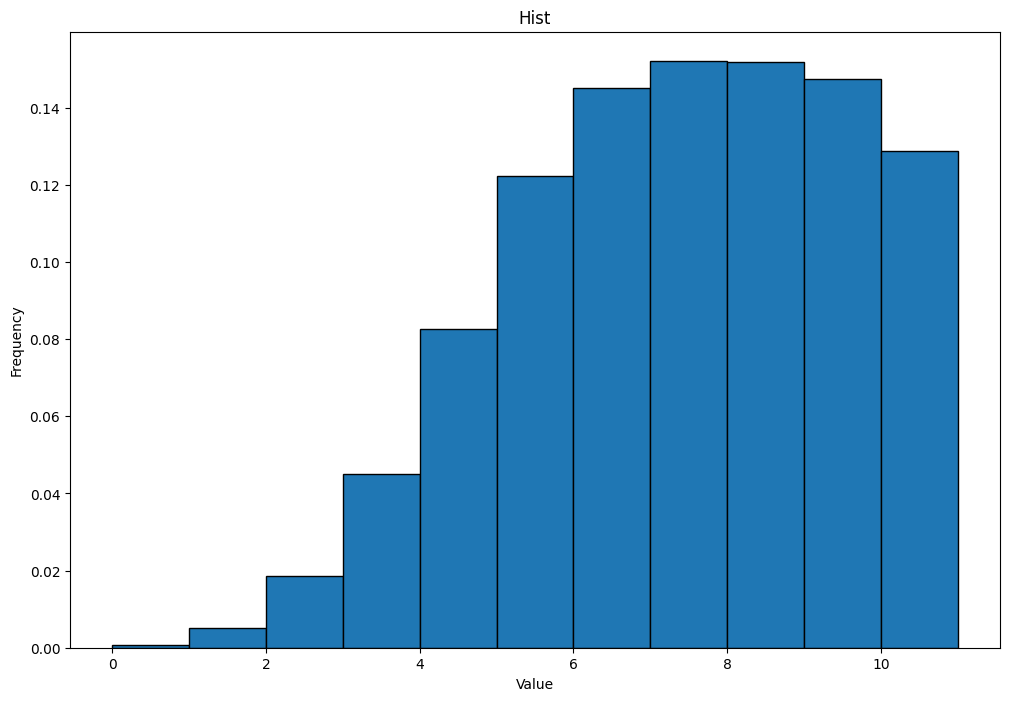

In [ ]:
m = 10

x1 = seed
lis = []
for I in range(300000):
    converge = 0
    while True:
        x2 = rd.randint(0,m)
        ratio = rd.random()
        if ratio < (math.factorial(x1)/math.factorial(x2))*(8**(x2-x1)):
            x1 = x2
            lis.append(x1)
            break
a = bar_hist(lis,center_on_int=True)
print(len(a))
print(chi(a,[0.000411163708159,0.00328930966527,0.0131572386611,0.0350859697629,0.0701719395258,0.112275103241,0.149700137655,0.171085871606,0.171085871606,0.152076330316,0.121661064253]))
    

In [ ]:
tot = 0
for I in range(10):
    for J in range(10):
        if I + J < 10:
           tot += (4**(I+J))/(math.factorial(I)*math.factorial(J))
print(tot)

#normalising constant

2136.2268077601407


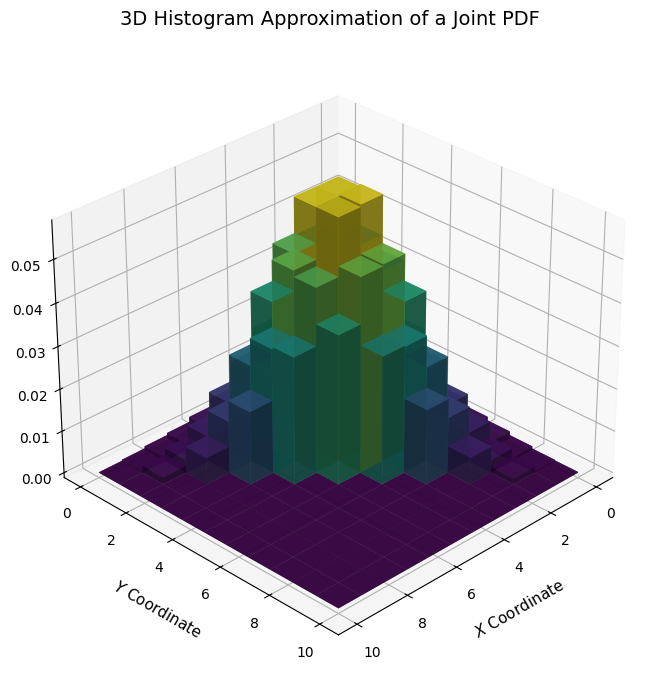

In [ ]:
m = 10
i = 0
j = 0
ilis = []
jlis = []

for I in range(300000):
    i_n = rd.randint(0, m)
    j_n = rd.randint(0, m)
    
    ratio = rd.random()

    if i_n + j_n <= m and ratio < ((math.factorial(i)*math.factorial(j))/(math.factorial(i_n)*math.factorial(j_n)))*(4**(i_n + j_n - i - j)):
        i = i_n
        j = j_n

    ilis.append(i)
    jlis.append(j)

ilis = ilis[50000:]
jlis = jlis[50000:]
Plot3dhis(ilis, jlis, bins=11, cmap_name='viridis')



plt.show()

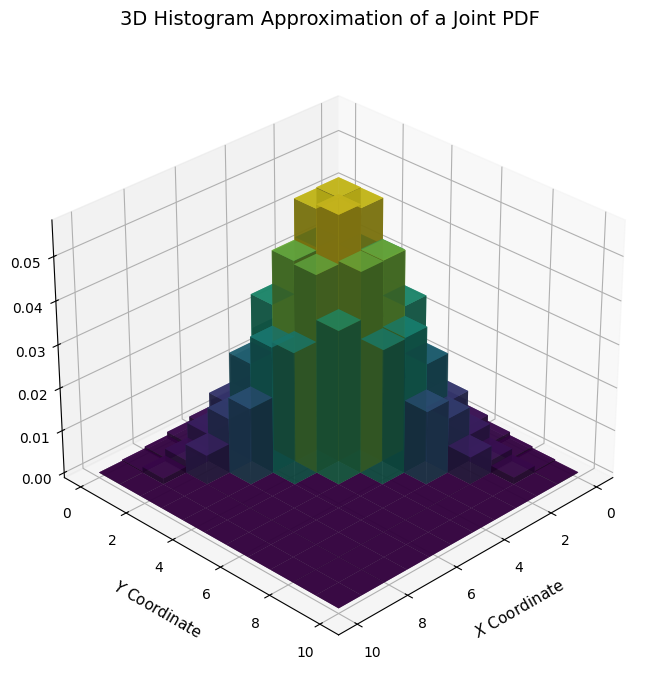

In [ ]:
m = 10
i = 0
j = 0
ilis = []
jlis = []

state = 1 

for I in range(300000):
    ratio = rd.random()
    if state == 1:   
        i_n = rd.randint(0, m)
        if i_n + j <= m and ratio < ((math.factorial(i)) / (math.factorial(i_n))) * (4**(i_n - i)):
            i = i_n
        state = 2 

    else:
        j_n = rd.randint(0, m)
        if i + j_n <= m and ratio < ((math.factorial(j)) / (math.factorial(j_n))) * (4**(j_n - j)):
            j = j_n
        state = 1
    ilis.append(i)
    jlis.append(j)


Plot3dhis(ilis, jlis, bins=11, cmap_name='viridis')
plt.show()


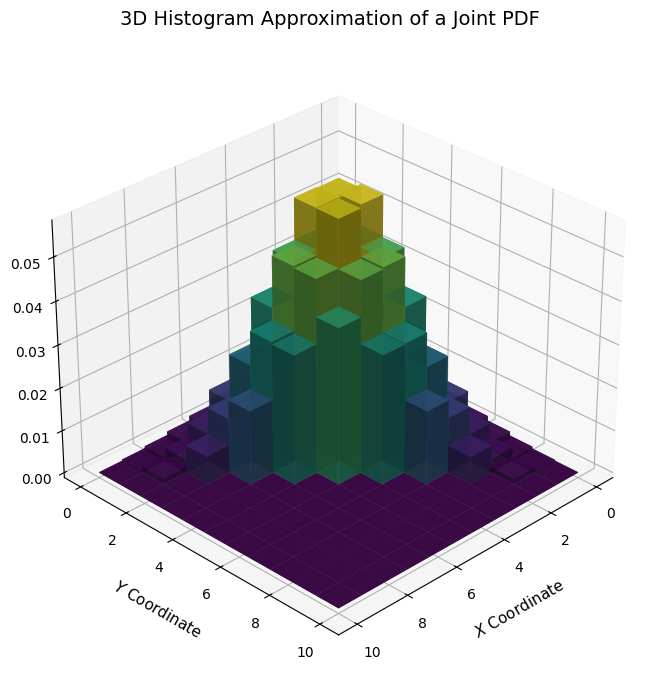

58.47135881369147 chi^2 val 
0.7033160279162111 p val 


In [ ]:
m = 10
i = 0
j = 0
ilis = []
jlis = []
for I in range(300000):
    mi = m - j
    ival = list(range(mi + 1))
    iw = [(4**k) / math.factorial(k) for k in ival]
    i = rd.choices(ival, weights=iw)[0]
    mj = m - i
    jval = list(range(mj + 1))
    jw = [(4**k) / math.factorial(k) for k in jval]
    j = rd.choices(jval, weights=jw)[0]
    ilis.append(i)
    jlis.append(j)
Plot3dhis(ilis, jlis, bins=11, cmap_name='viridis')
plt.show()



m=10
valid= []
theoretical_probs = []

for i_val in range(m + 1):
    for j_val in range(m + 1):
        if i_val + j_val <= m:
            valid.append((i_val, j_val))
            prob =  2136.2268077601407*(4**i_val / math.factorial(i_val)) * (4**j_val / math.factorial(j_val))
            theoretical_probs.append(prob)

theoretical_probs = np.array(theoretical_probs)
theoretical_probs /= theoretical_probs.sum()

obcounts = {}
for state in valid:
    obcounts[state] = 0

# Count the pairs from your simulation
for k in range(len(ilis)):
    pair = (ilis[k], jlis[k])
    if pair in obcounts:
      obcounts[pair] += 1

total_samples = len(ilis)
observed_counts = np.array([obcounts[state] for state in valid])
expected_counts = theoretical_probs * total_samples

chi2_stat, p_value = st.chisquare(f_obs=observed_counts, f_exp=expected_counts)
print(str(chi2_stat) + " chi^2 val ")
print(str(p_value) + " p val ")

In [541]:
def generate_prior_sample(rho=0.5):
    z0 = Normal_dis()[0]
    z1 = Normal_dis()[1]

    g = rho * z0 + math.sqrt(1.0 - rho**2) * z1

    a = math.exp(z0)
    b = math.exp(g)

    return a, b


def simulate_observations(theta, psi, n=10):
    observations = []
    for _ in range(n):
        z0 = Normal_dis()[0]

        x_i = theta + math.sqrt(psi) * z0
        observations.append(x_i)
    return observations


theta_sample, psi_sample = generate_prior_sample()
simulated_data = simulate_observations(theta_sample, psi_sample, n=10)
print(simulated_data)


seed = 0
m = 10
i = 0
j = 0
ilis = []
jlis = []

for I in range(300000):
    i_n = rd.randint(0, m)
    j_n = rd.randint(0, m)
    
    ratio = rd.random()

    #if i_n + j_n <= m and ratio < :  I do not know how to do this right now so I will have to come back in the future when I have more time to read up on this
    #    i = i_n
    #    j = j_n

    ilis.append(i)
    jlis.append(j)

ilis = ilis[50000:]
jlis = jlis[50000:]


[-0.7479828526294108, 0.7689994476207266, 0.5157299417030303, -0.7084999664920217, 0.8726425043813242, -0.013712872075686888, -0.2967498731147574, 0.611868635725348, 0.05806666406880023, 0.4720658140593416]


Exersize 7

In [552]:
def dis(path, pos):
    tot_sum = 0
    n = len(path)
    
    for i in range(n):
        curr_id = path[i]
        next_id = path[(i + 1) % n]
        p1 = pos[curr_id]
        p2 = pos[next_id]
        dist = math.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2)
        tot_sum += dist   
    return tot_sum

print(dis([0,1],[(1,0),(1,1)]))


2.0


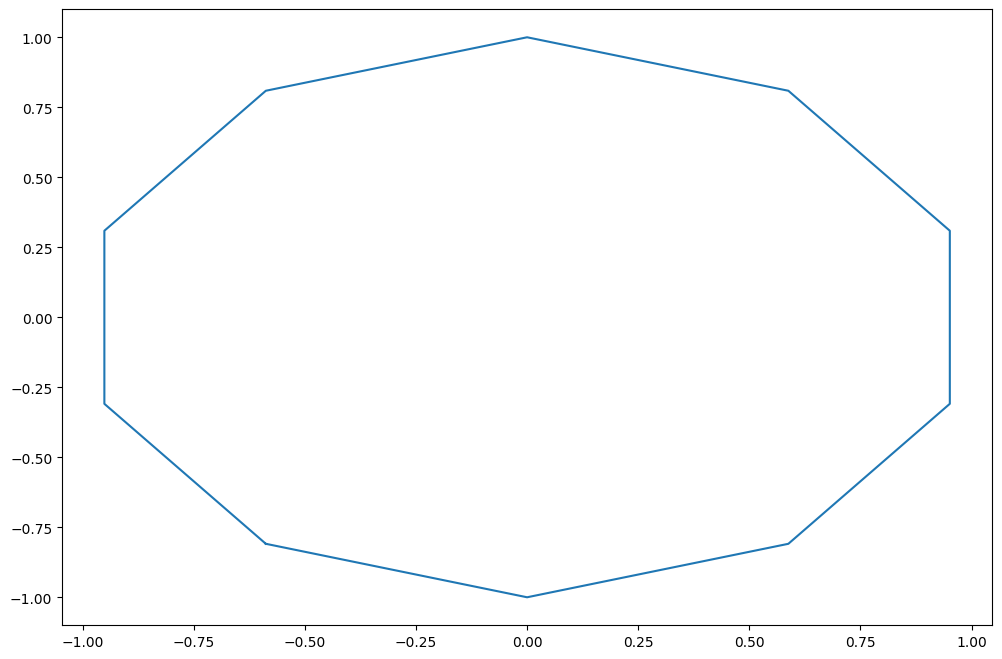

In [562]:
def annealing(pos, iter):
    
    current = [I for I in range(len(positions))]
    best = current[:]
    
    def dis(path, pos2):
        tot_sum = 0
        n = len(path)

        for i in range(n):
            curr_id = path[i]
            next_id = path[(i + 1) % n]
            p1 = pos2[curr_id]
            p2 = pos2[next_id]
            dist = math.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2)
            tot_sum += dist   
        return tot_sum


    best_d = dis(best, pos)

    def cooling_scheme(k):
        return 1/math.sqrt(1+k)
    
    for k in range(iter):

        tk = cooling_scheme(k)

        n1=rd.randint(0,len(current)-1)
        n2 = rd.randint(0,len(current)-1)
        new = current[:]
        tem = new[n1]
        new[n1] = new[n2]
        new[n2] = tem

        Cx = dis(current, positions)
        Cy = dis(new, positions)
       
        # The Metropolis-Hastings acceptance criterion
        if Cy - Cx < 0 or rd.random() < math.exp((-(Cy - Cx)) / tk):
            current = new
            Cx = Cy

        # finding best distance
        if Cx < best_d:
            best = current[:]
            best_d = Cx

    return best, best_d



positions = [(math.sin(2*math.pi*i/10), math.cos(2*math.pi*i/10)) for i in range(10)]

rd.shuffle(positions)

a, b = annealing(positions, 1000)

x = [positions[i][0] for i in a]
y = [positions[j][1] for j in a]
x.append(x[0]) 
y.append(y[0])
plt.plot(x, y)
plt.show()


In [ ]:
def annealing(pos, iter):
    
    current = [I for I in range(len(positions))]
    best = current[:]
    
    def dis(path, pos2, cost_table):
        tot_sum = 0
        n = len(path)

        for i in range(n):
            curr_id = path[i]
            next_id = path[(i + 1) % n]
            p1 = pos2[curr_id]
            p2 = pos2[next_id]
            dist = cost_table[p1][p2]
            tot_sum += dist   
        return tot_sum


    best_d = dis(best, pos)

    def cooling_scheme(k):
        return 1/math.sqrt(1+k)
    
    for k in range(iter):

        tk = cooling_scheme(k)

        n1=rd.randint(0,len(current)-1)
        n2 = rd.randint(0,len(current)-1)
        new = current[:]
        tem = new[n1]
        new[n1] = new[n2]
        new[n2] = tem

        Cx = dis(current, positions)
        Cy = dis(new, positions)
       
        if Cy - Cx < 0 or rd.random() < math.exp((-(Cy - Cx)) / tk):
            current = new
            Cx = Cy
        if Cx < best_d:
            best = current[:]
            best_d = Cx

    return best, best_d



positions = [(math.sin(2*math.pi*i/10), math.cos(2*math.pi*i/10)) for i in range(10)]

rd.shuffle(positions)

a, b = annealing(positions, 1000)

x = [positions[i][0] for i in a]
y = [positions[j][1] for j in a]
x.append(x[0]) 
y.append(y[0])
plt.plot(x, y)
plt.show()

In [ ]:
import csv
def annealing(pos, iter, table):
    
    current = [I for I in range(len(positions))]
    best = current[:]
    
    def dis(path, pos2, cost_table):
        tot_sum = 0
        n = len(path)

        for i in range(n):
            curr_id = path[i]
            next_id = path[(i + 1) % n]
            p1 = pos2[curr_id]
            p2 = pos2[next_id]
            dist = cost_table[p1][p2]
            tot_sum += dist   
        return tot_sum


    best_d = dis(best, pos, table)

    def cooling_scheme(k):
        return 1/math.sqrt(1+k)
    
    for k in range(iter):

        tk = cooling_scheme(k)

        n1=rd.randint(0,len(current)-1)
        n2 = rd.randint(0,len(current)-1)
        new = current[:]
        tem = new[n1]
        new[n1] = new[n2]
        new[n2] = tem

        Cx = dis(current, positions, table)
        Cy = dis(new, positions, table)
       
        if Cy - Cx < 0 or rd.random() < math.exp((-(Cy - Cx)) / tk):
            current = new
            Cx = Cy

        if Cx < best_d:
            best = current[:]
            best_d = Cx

    return best, best_d



cost_table = []
with open('cost.csv', 'r') as f:
    reader = csv.reader(f)
    for row in reader:
        cost_table.append([float(val) for val in row])

positions = [i for i in range(len(cost_table))]
rd.shuffle(positions)

a, b = annealing(positions, 1000, cost_table)

print(f"Best Route: {a}")
print(f"Best Cost: {b}")


Best Route: [8, 0, 13, 16, 7, 17, 11, 10, 14, 4, 1, 6, 9, 15, 3, 12, 5, 18, 2, 19]
Best Cost: 883.0


Exersize 8

In [ ]:
data = [56,101,78,67,93,87,64,72,80,69]
B = 10000
counts = 0
sum1 = 0

for P in range(B):
    sum1 += float(np.random.choice(data))
mean = sum1/B
for L in range(B):
    sum1 = 0
    for I in range(10):
        sum1 += float(np.random.choice(data))
    if (sum1/B-mean) > -5 and (sum1/B-mean < 5):
        count += 1
print(count/10)


69
2.4714615629472947


In [598]:
data = [5, 4, 9, 6, 21, 17, 11, 20, 7, 10, 21, 15, 13, 16, 8]
vararray = []

for L in range(10000):
    varsamp = []
    for I in range(len(data)):
        varsamp.append(rd.choice(data))
    vararray.append(np.var(varsamp))
print(np.var(vararray))

52.3598045814803
